# investalyze — price-segment explorer

Chop selected price series into fixed-length, **rebased-to-100** segment vectors via
`investalyze.analysis.segments`. This notebook just drives the module and sanity-checks the
output — clustering and the next-segment (transition) analysis come later.

Change `CLASSES` / `TICKERS` / `LENGTH` / `STRIDE` and re-run.

In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np

from helpers import connect_readonly
from investalyze.analysis import segments

con = connect_readonly()

## Selection

Pick broadly by class (`stocks`, `indices`, `bonds`, `currencies`) and/or finely by ticker.

In [2]:
CLASSES = ['stocks', 'indices']
TICKERS = ['AAPL', 'MSFT', '^DJI', '^NDX']  # set to None for every ticker in the chosen classes
LENGTH = 20   # trading rows per segment
STRIDE = 20   # step between segment starts (== LENGTH -> non-overlapping)

series = segments.load_series(con, classes=CLASSES, tickers=TICKERS)
series.groupby(['AssetClass', 'Ticker']).size()

AssetClass  Ticker
indices     ^DJI      33661
            ^NDX      22842
stocks      AAPL      11474
            MSFT      10148
dtype: int64

## Build segments

In [3]:
X, meta, successor = segments.build_segments(series, length=LENGTH, stride=STRIDE)
print('X         ', X.shape)
print('segments  ', len(meta))
print('w/ succ.  ', int((successor >= 0).sum()))
meta.head()

X          (3905, 20)
segments   3905
w/ succ.   3901


,segment_id,Ticker,AssetClass,start_date,end_date,start_idx
0,0,AAPL,stocks,1980-12-12,1981-01-12,0
1,1,AAPL,stocks,1981-01-13,1981-02-09,20
2,2,AAPL,stocks,1981-02-10,1981-03-10,40
3,3,AAPL,stocks,1981-03-11,1981-04-07,60
4,4,AAPL,stocks,1981-04-08,1981-05-06,80


## Sanity plot — a few rebased segments

Every segment must start at 100; shapes overlay regardless of original price level.

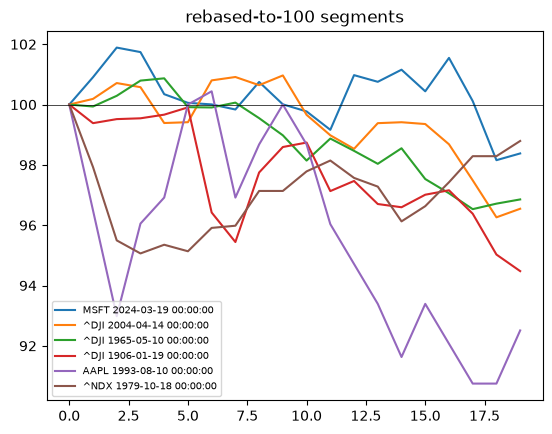

In [4]:
rng = np.random.default_rng(0)
sample = rng.choice(len(X), size=min(6, len(X)), replace=False)
for i in sample:
    plt.plot(X[i], label=f"{meta.loc[i, 'Ticker']} {meta.loc[i, 'start_date']}")
plt.axhline(100, color='k', lw=0.5)
plt.title('rebased-to-100 segments')
plt.legend(fontsize=7)
plt.show()

## Successor example

A segment and the contiguous block `LENGTH` rows later — the unit the transition layer will study.

In [5]:
s = int(np.flatnonzero(successor >= 0)[0])
cols = ['Ticker', 'start_date', 'end_date', 'start_idx']
print('segment  ', meta.loc[s, cols].to_dict())
print('successor', meta.loc[successor[s], cols].to_dict())

segment   {'Ticker': 'AAPL', 'start_date': Timestamp('1980-12-12 00:00:00'), 'end_date': Timestamp('1981-01-12 00:00:00'), 'start_idx': 0}
successor {'Ticker': 'AAPL', 'start_date': Timestamp('1981-01-13 00:00:00'), 'end_date': Timestamp('1981-02-09 00:00:00'), 'start_idx': 20}


In [6]:
meta

,segment_id,Ticker,AssetClass,start_date,end_date,start_idx
0,0,AAPL,stocks,1980-12-12,1981-01-12,0
1,1,AAPL,stocks,1981-01-13,1981-02-09,20
2,2,AAPL,stocks,1981-02-10,1981-03-10,40
3,3,AAPL,stocks,1981-03-11,1981-04-07,60
4,4,AAPL,stocks,1981-04-08,1981-05-06,80
...,...,...,...,...,...,...
3900,3900,^NDX,indices,2026-01-23,2026-02-20,22740
3901,3901,^NDX,indices,2026-02-23,2026-03-20,22760
3902,3902,^NDX,indices,2026-03-23,2026-04-20,22780
3903,3903,^NDX,indices,2026-04-21,2026-05-18,22800
